In [1]:
%pip install -r ../requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# path relativ conform structurii tale :contentReference[oaicite:0]{index=0}
META_PATH = "../Data/processed_meld_emotieff/v1_enet_b2_7_gtprob_gap0p3s/metadata_train.csv"

df = pd.read_csv(META_PATH)

print(df.shape)
df.head()

(49003, 22)


,split,dialogue_id,utterance_id,speaker,emotion,emotion_norm,video_path,fps,total_frames,frame_idx,...,gt_prob,pred_label,pred_prob,bbox_x1,bbox_y1,bbox_x2,bbox_y2,image_path,analysis_npz,status
0,train,0,0,Chandler,neutral,Neutral,../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4,23.976024,136,9.0,...,0.449353,Neutral,0.449353,921.0,132.0,994.0,232.0,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,ok
1,train,0,0,Chandler,neutral,Neutral,../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4,23.976024,136,43.0,...,0.396023,Anger,0.498756,950.0,122.0,1022.0,217.0,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,ok
2,train,0,0,Chandler,neutral,Neutral,../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4,23.976024,136,31.0,...,0.273704,Anger,0.572878,932.0,130.0,1005.0,229.0,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,ok
3,train,0,0,Chandler,neutral,Neutral,../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4,23.976024,136,24.0,...,0.243758,Anger,0.615971,922.0,136.0,994.0,236.0,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,ok
4,train,0,0,Chandler,neutral,Neutral,../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4,23.976024,136,16.0,...,0.240161,Anger,0.628873,912.0,129.0,986.0,231.0,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,../Data/processed_meld_emotieff\v1_enet_b2_7_g...,ok


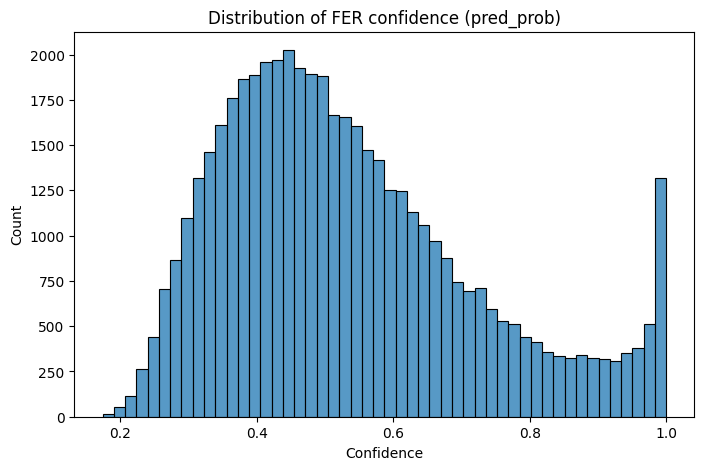

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["pred_prob"], bins=50)
plt.title("Distribution of FER confidence (pred_prob)")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

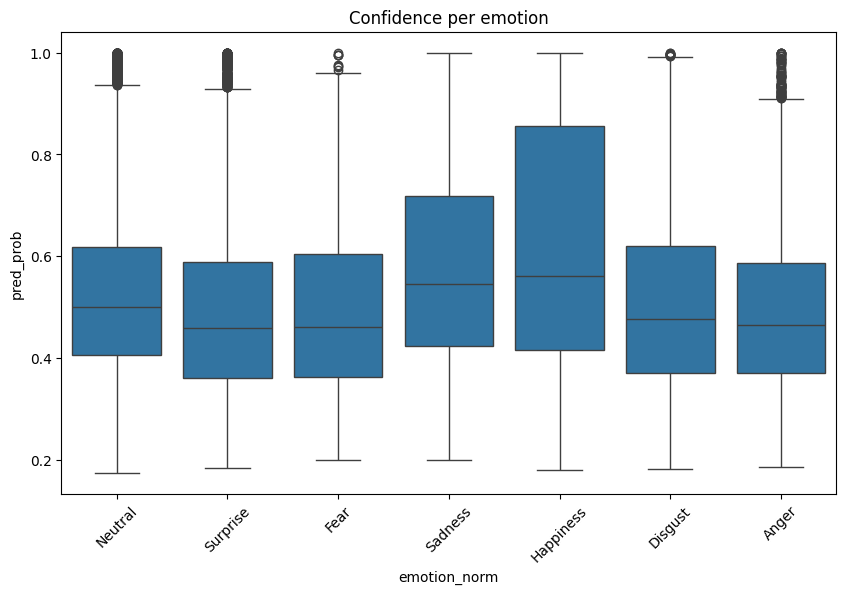

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="emotion_norm", y="pred_prob")
plt.xticks(rotation=45)
plt.title("Confidence per emotion")
plt.show()

In [2]:
df["correct"] = df["pred_label"] == df["emotion_norm"]

accuracy = df["correct"].mean()
print(f"Agreement with GT (proxy accuracy): {accuracy:.4f}")

Agreement with GT (proxy accuracy): 0.4133


emotion_norm
Surprise     0.105522
Fear         0.228097
Disgust      0.312268
Anger        0.332843
Happiness    0.452677
Neutral      0.487308
Sadness      0.587906
Name: correct, dtype: float64


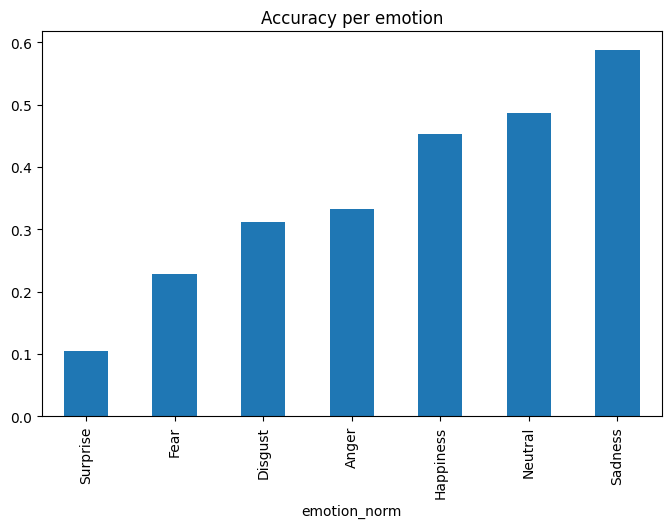

In [3]:
acc_per_class = df.groupby("emotion_norm")["correct"].mean().sort_values()

print(acc_per_class)

acc_per_class.plot(kind="bar", figsize=(8,5), title="Accuracy per emotion")
plt.show()

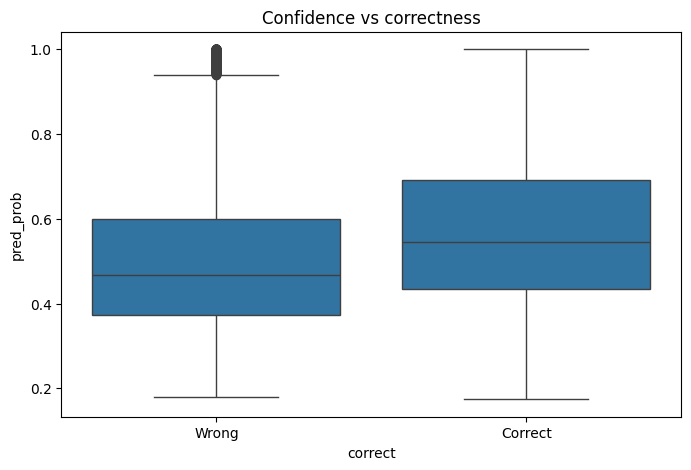

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="correct", y="pred_prob")
plt.title("Confidence vs correctness")
plt.xticks([0,1], ["Wrong", "Correct"])
plt.show()

selection_rank
0.0    0.623721
1.0    0.473316
2.0    0.373713
3.0    0.306727
4.0    0.282622
Name: correct, dtype: float64


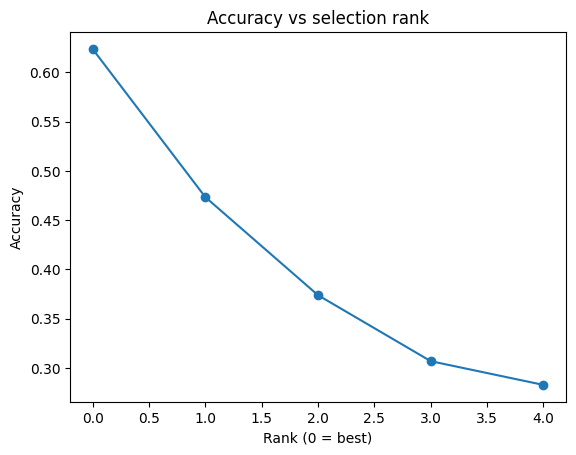

In [10]:
rank_acc = df.groupby("selection_rank")["correct"].mean()

print(rank_acc)

rank_acc.plot(marker="o", title="Accuracy vs selection rank")
plt.xlabel("Rank (0 = best)")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
thresholds = [0.3, 0.5, 0.7, 0.8]

for t in thresholds:
    sub = df[df["pred_prob"] >= t]
    if len(sub) == 0:
        continue
    acc = (sub["pred_label"] == sub["emotion_norm"]).mean()
    print(f"Threshold {t}: size={len(sub)}, acc={acc:.4f}")

Threshold 0.3: size=45875, acc=0.4263
Threshold 0.5: size=24368, acc=0.4999
Threshold 0.7: size=8881, acc=0.5488
Threshold 0.8: size=5333, acc=0.5968


: 

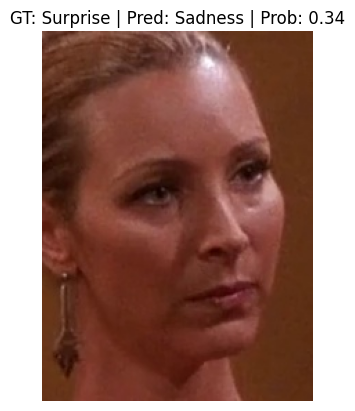

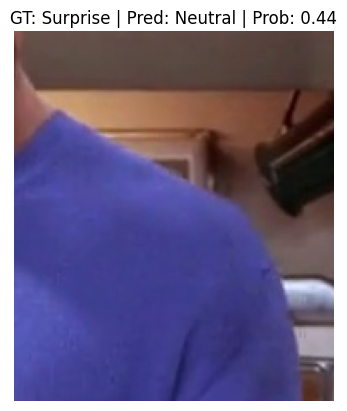

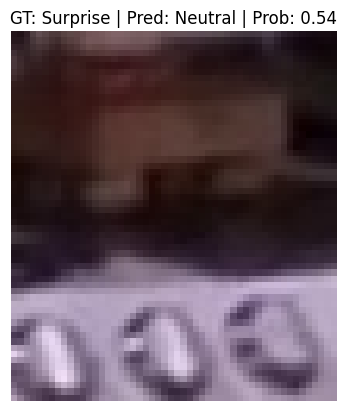

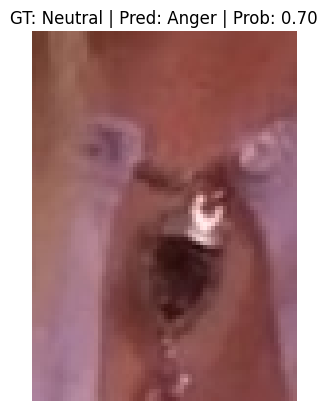

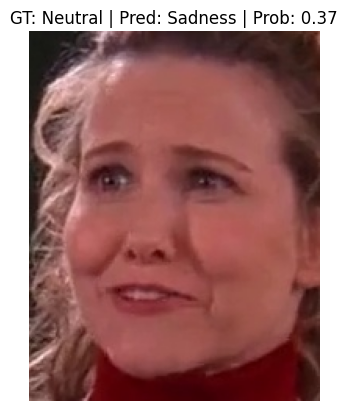

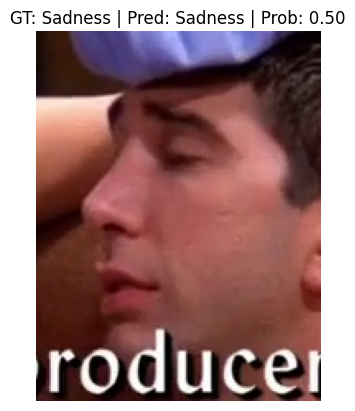

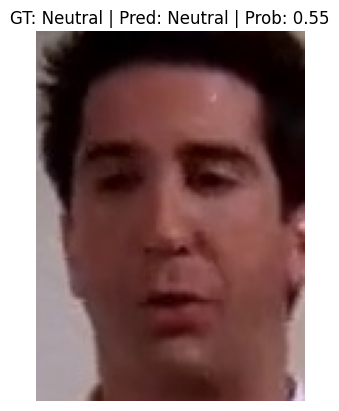

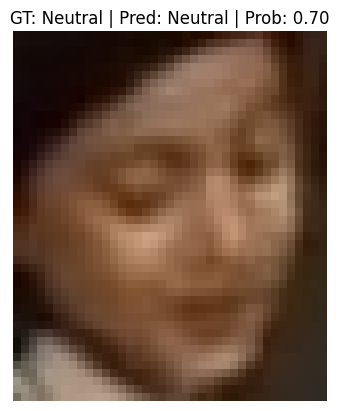

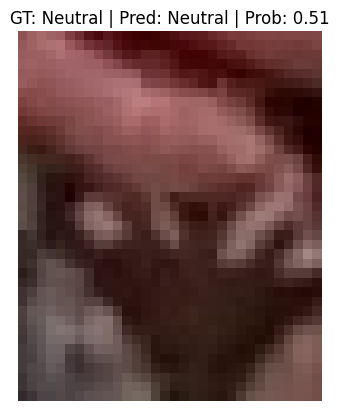

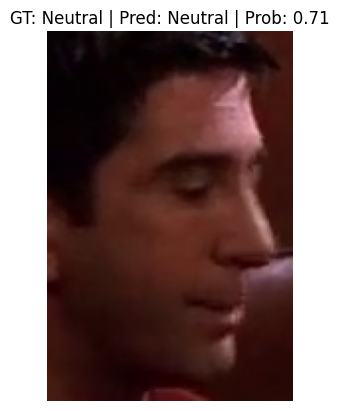

In [12]:
import cv2
import random

def show_samples(df, condition, n=5):
    samples = df[condition].sample(n)
    
    for _, row in samples.iterrows():
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.imshow(img)
        plt.title(
            f"GT: {row['emotion_norm']} | Pred: {row['pred_label']} | Prob: {row['pred_prob']:.2f}"
        )
        plt.axis("off")
        plt.show()

# exemple proaste
show_samples(df, df["correct"] == False, n=5)

# exemple bune
show_samples(df, df["correct"] == True, n=5)